# 04 · Enterprise stress testing dan capital overlay

> Fictional Islamic bank, fully synthetic data. Semua logika ada di `src/erm/`; notebook hanya narasi dan visual.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd
from erm import datastore, kri, scoring, validation

In [2]:
out = datastore.load_outputs()
out['stress_risk_scores'].pivot(index='risk_type', columns='scenario', values='final_score')[datastore.SCENARIOS]

scenario,baseline,adverse,severe
risk_type,,,
Compliance,3.60,3.6,3.60
Credit,3.00,3.5,4.00
Investment,2.20,3.0,3.50
Legal,2.20,2.2,2.20
Liquidity,2.65,3.0,4.45
Market,2.30,3.5,3.50
Operational,3.60,3.8,4.45
Rate of Return,3.10,3.7,4.20
Reputation,2.60,3.5,3.50


In [3]:
out['stress_enterprise_summary']

,scenario,enterprise_score,rating,limit_utilization,tolerance_breaches,limit_breaches
0,baseline,2.9545,Moderate,67.970980,9,0
1,adverse,3.4020,Moderate,77.624312,14,6
2,severe,3.9555,Moderate to High,93.171764,21,14


In [4]:
out['stress_waterfall'].query("to_scenario == 'severe'")

,from_scenario,to_scenario,step,driver,contribution,cumulative
13,baseline,severe,0,Enterprise baseline,2.9545,2.9545
14,baseline,severe,1,Liquidity,0.2700,3.2245
15,baseline,severe,2,Credit,0.2500,3.4745
16,baseline,severe,3,Rate of Return,0.1100,3.5845
17,baseline,severe,4,Operational,0.1020,3.6865
18,baseline,severe,5,Investment,0.0910,3.7775
19,baseline,severe,6,Strategic,0.0640,3.8415
20,baseline,severe,7,Market,0.0600,3.9015
21,baseline,severe,8,Reputation,0.0540,3.9555
22,baseline,severe,9,Compliance,0.0000,3.9555


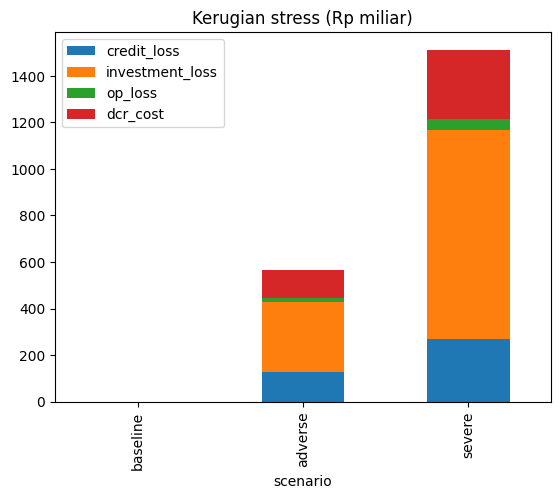

In [5]:
out['capital_overlay'].set_index('scenario')[['credit_loss', 'investment_loss', 'op_loss', 'dcr_cost']].plot.bar(stacked=True, title='Kerugian stress (Rp miliar)');